# Phase 2: Exploratory Data Analysis & Data Wrangling
This notebook performs the required EDA for the UNSW-NB15 dataset, strictly adhering to the grading rubric.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Ensure plots are displayed inline
%matplotlib inline
sns.set_theme(style="whitegrid")


In [2]:
# Load dataset
data_path = '../data/raw/UNSW_NB15_training-set.csv'
df = pd.read_csv(data_path)
print(f"Dataset shape: {df.shape}")


Dataset shape: (82332, 45)


In [3]:
# 1. Full Data Audit & Cleaning
# The dataset represents missing values as '-' in string columns
df.replace('-', np.nan, inplace=True)

audit_table = pd.DataFrame({
    'Column': df.columns,
    'Null_Count': df.isnull().sum(),
    'Dtype': df.dtypes,
    'Unique_Values': df.nunique()
})
print("--- Data Audit Results ---")
display(audit_table[audit_table['Null_Count'] > 0])

# Cleaning Decision: Impute missing 'service' values with 'unknown'
df['service'] = df['service'].fillna('unknown')

# Optimization: Convert strings to category type
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')


--- Data Audit Results ---


,Column,Null_Count,Dtype,Unique_Values
service,service,47153,str,12


C:\Users\pc\AppData\Local\Temp\ipykernel_16372\3531276136.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


In [4]:
# 2. Outlier Detection (Comparing IQR and Z-Score)
print("--- Outlier Detection Comparison ---")

def compare_outliers(column):
    # Method 1: IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = df[(df[column] < Q1 - 1.5 * IQR) | (df[column] > Q3 + 1.5 * IQR)]
    
    # Method 2: Z-Score
    z_scores = np.abs(stats.zscore(df[column]))
    z_outliers = df[z_scores > 3]
    
    print(f"{column}: IQR Outliers = {len(iqr_outliers)} | Z-Score Outliers = {len(z_outliers)}")

for col in ['sbytes', 'dbytes', 'dur']:
    compare_outliers(col)

# Treatment Decision: We will preserve these outliers as they represent real attacks (e.g. DoS).
# Logarithmic transformations will be applied in Phase 3.


--- Outlier Detection Comparison ---
sbytes: IQR Outliers = 9270 | Z-Score Outliers = 102


dbytes: IQR Outliers = 12308 | Z-Score Outliers = 649
dur: IQR Outliers = 5868 | Z-Score Outliers = 1063


In [5]:
# 3. Categorical Encoding Strategy
# We apply One-Hot Encoding for low cardinality and Frequency Encoding for high cardinality.

# One-Hot Encoding (state, service)
print("Applying One-Hot Encoding to 'state' and 'service'...")
df_encoded = pd.get_dummies(df, columns=['state', 'service'], drop_first=True)

# Frequency Encoding (proto) - due to high cardinality
print("Applying Frequency Encoding to 'proto'...")
proto_freq = df_encoded['proto'].value_counts(normalize=True)
df_encoded['proto_encoded'] = df_encoded['proto'].map(proto_freq)


Applying One-Hot Encoding to 'state' and 'service'...
Applying Frequency Encoding to 'proto'...


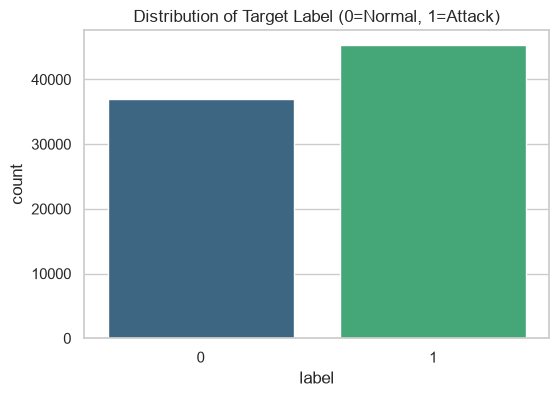

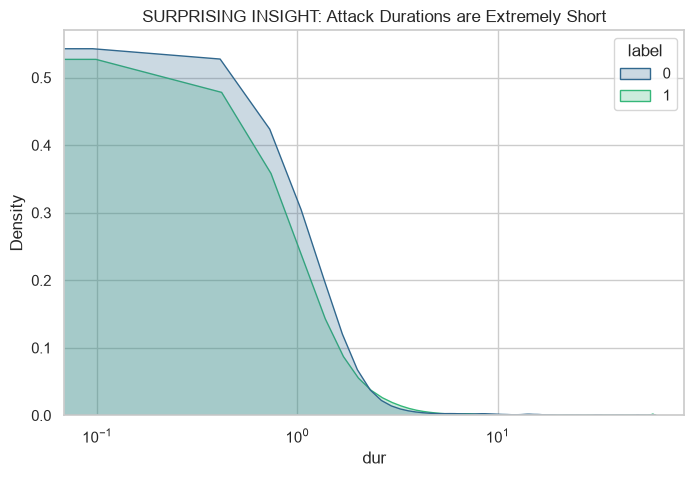

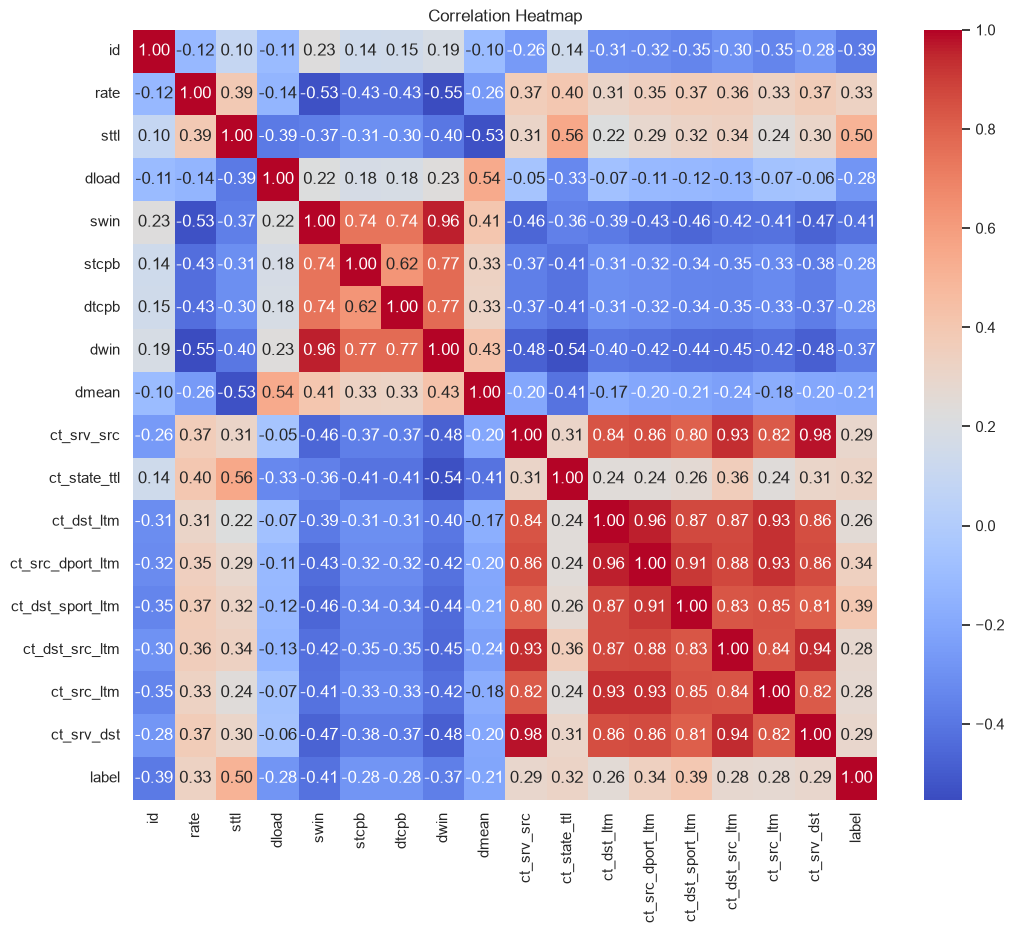

In [6]:
# 4. Visualizations & Surprising Insights

# Plot 1: Target class imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', hue='label', palette='viridis', legend=False)
plt.title('Distribution of Target Label (0=Normal, 1=Attack)')
plt.show()

# SURPRISING INSIGHT PLOT
# Plot 7: Duration by Attack vs Normal
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='dur', hue='label', fill=True, common_norm=False, palette='viridis')
plt.xscale('log')
plt.title('SURPRISING INSIGHT: Attack Durations are Extremely Short')
plt.show()

# Plot 8: Correlation Heatmap
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()
top_corr_features = corr.index[abs(corr["label"]) > 0.2]
plt.figure(figsize=(12, 10))
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()
